In [17]:
from __future__ import print_function  # Memastikan kompatibilitas fungsi keluaran (print) pada berbagai versi lingkungan Python

#%matplotlib inline                    # Menginstruksikan kernel agar visualisasi grafik dirender langsung di dalam sel notebook

import numpy                 # Mengimpor pustaka NumPy untuk komputasi numerik dan manipulasi array multidimensi
import matplotlib.pyplot as plt       # Mengimpor modul Pyplot sebagai instrumen utama dalam pembuatan visualisasi data ilmiah

# **Perbedaan Terbatas(Finite Differences)**

Beda hingga adalah ekspresi yang memperkirakan turunan suatu fungsi yang dievaluasi pada sekumpulan titik, yang sering disebut *stensil*.  Ekspresi ini dapat hadir dalam berbagai bentuk termasuk jenis stensil, urutan keakuratan, dan urutan turunannya.  Pada kuliah kali ini kita akan mengulas proses derivasi, analisis kesalahan dan penerapan beda hingga.

## **Penurunan Perbedaan Hingga(Derivation of Finite Differences)**

Pendekatan umum untuk menurunkan perbedaan hingga harusnya sudah familiar setidaknya untuk perbedaan orde pertama.  Pertimbangkan tiga cara berbeda untuk mendefinisikan turunan pada titik $x_i$ 
 $$
    u'(x_i) = \lim_{\Delta x \rightarrow 0} \left \{ \begin{aligned} 
        &\frac{u(x_i + \Delta x) - u(x_i)}{\Delta x} & \equiv D_+ u(x_i)\\
        &\frac{u(x_i + \Delta x) - u(x_i - \Delta_x)}{2 \Delta x} & \equiv D_0 u(x_i)\\
        &\frac{u(x_i) - u(x_i - \Delta_x)}{\Delta x} & \equiv D_- u(x_i).
    \end{aligned} \right .
$$ 

![Perkiraan ke $u'(x)$ ](./images/fd_basic.png)

Jika alih-alih mengizinkan $\Delta x \rightarrow 0$, kita membuat perkiraan terhadap kemiringan $u'(x_i)$ dan karenanya definisi turunan kita dapat secara langsung dilihat sebagai perkiraan terhadap turunan ketika $\Delta x$ mungkin kecil namun bukan nol.

Untuk sisa tinjauan ini, kami akan mempelajari cara yang lebih sistematis untuk memperoleh perkiraan ini serta menemukan perkiraan akurat tingkat tinggi, perkiraan turunan tingkat tinggi, dan memahami kesalahan yang terkait dengan perkiraan tersebut.

### **Interpolasi Polinomial(Interpolating Polynomials)**

Salah satu cara untuk memperoleh perkiraan beda hingga adalah dengan mencari polinomial interpolasi melalui stensil yang diberikan dan membedakannya secara langsung.  Mengingat poin $N+1$ $(x_0,u(x_0)), (x_1,u(x_1)), \ldots, (x_{N},u(x_{N}))$ dengan asumsi $x_i$ semuanya unik, polinomial interpolasi $P_N(x)$ dapat ditulis sebagai

 $$
    P_N(x) = \sum^{N}_{i=0} u(x_i) \ell_i(x)
$$ 

dimana 

 $$
    \ell_i(x) = \prod^{N}_{j=0, j \neq i} \frac{x - x_j}{x_i - x_j} = \frac{x - x_0}{x_i - x_0} \frac{x - x_1}{x_i - x_1} \cdots \frac{x - x_{i-1}}{x_i - x_{i-1}}\frac{x - x_{i+1}}{x_i - x_{i+1}} \cdots \frac{x - x_{N}}{x_i - x_{N}}
$$

Perhatikan bahwa $\ell_i(x_i) = 1$ dan $\forall j\neq i, ~~ \ell_i(x_j) = 0$ .  

Karena kita mengetahui cara membedakan polinomial, kita seharusnya dapat menghitung perkiraan perbedaan hingga yang diberikan berdasarkan titik-titik data ini.

#### Contoh: Stensil 2 Titik

Katakanlah kita mempunyai dua titik untuk membentuk perkiraan turunan dengan.  Polinomial interpolasi melalui dua titik merupakan fungsi linier dengan bentuk
 $$
    P_1(x) = u(x_0) \frac{x - x_1}{x_0 - x_1} + u(x_1) \frac{x - x_0}{x_1 - x_0}.
$$ 
Turunkan perkiraan yang berpusat di $x_0$ dari polinomial ini.

Membedakan $P_1(x)$ mengarah ke
 $$
    P'_1(x) = u(x_0) \frac{1}{x_0 - x_1} + u(x_1) \frac{1}{x_1 - x_0}.
$$

Jika kita mengizinkan jarak antara $x_0$ dan $x_1$ menjadi $\Delta x = x_1 - x_0$ maka kita dapat menulisnya sebagai
 $$
    P'_1(x) = \frac{u(x_1) - u(x_0)}{\Delta x}
$$ 
yang merupakan bentuk umum dari $D_-u(x)$ dan $D_+u(x)$ diatas.

Jika kita memperluasnya hingga memiliki tiga titik, kita memiliki polinomial interpolasi
 $$
    P_2(x) = u(x_0) \frac{x - x_1}{x_0 - x_1} \frac{x - x_2}{x_0 - x_2} + u(x_1) \frac{x - x_0}{x_1 - x_0} \frac{x - x_2}{x_1 - x_2} + u(x_2) \frac{x - x_0}{x_2 - x_0} \frac{x - x_1}{x_2 - x_1}.
$$

Membedakan hal ini mengarah pada
 $$\begin{aligned}
    P'_2(x) &= u(x_0) \left( \frac{1}{x_0 - x_1} \frac{x - x_2}{x_0 - x_2} + \frac{x - x_1}{x_0 - x_1} \frac{1}{x_0 - x_2}\right )+ u(x_1) \left ( \frac{1}{x_1 - x_0} \frac{x - x_2}{x_1 - x_2} + \frac{x - x_0}{x_1 - x_0} \frac{1}{x_1 - x_2} \right )+ u(x_2)\left ( \frac{1}{x_2 - x_0} \frac{x - x_1}{x_2 - x_1} + \frac{x - x_0}{x_2 - x_0} \frac{1}{x_2 - x_1} \right ) \\
    &= u(x_0) \left(\frac{x - x_2}{2 \Delta x^2} + \frac{x - x_1}{2 \Delta x^2} \right )+ u(x_1) \left ( \frac{x - x_2}{-\Delta x^2} + \frac{x - x_0}{-\Delta x^2} \right )+ u(x_2)\left ( \frac{x - x_1}{2\Delta x^2} + \frac{x - x_0}{2 \Delta x^2} \right ) \\
    &=\frac{u(x_0)}{2\Delta x^2} (2x - x_2 - x_1)+ \frac{u(x_1)}{-\Delta x^2} ( 2x - x_2 - x_0)+ \frac{u(x_2)}{2\Delta x^2}( 2x - x_1 - x_0) \\
    &=\frac{u(x_0)}{2\Delta x^2} (2x - x_2 - x_1)+ \frac{u(x_1)}{-\Delta x^2} ( 2x - x_2 - x_0)+ \frac{u(x_2)}{2\Delta x^2}( 2x - x_1 - x_0).
\end{aligned}$$

Jika sekarang kita mengevaluasi turunannya di $x_1$ , dengan asumsi ini adalah titik pusatnya, kita punya
 $$\begin{aligned}
    P'_2(x_1) &= \frac{u(x_0)}{2\Delta x^2} (x_1 - x_2)+ \frac{u(x_1)}{-\Delta x^2} ( x_1 - x_2 + x_1 - x_0)+ \frac{u(x_2)}{\Delta x^2}( x_1 - x_0) \\
    &= \frac{u(x_0)}{2\Delta x^2} (-\Delta x)+ \frac{u(x_1)}{-\Delta x^2} ( -\Delta x + \Delta x)+ \frac{u(x_2)}{\Delta x^2}( 2\Delta x) \\
    &= \frac{u(x_2) - u(x_0)}{2 \Delta x}
\end{aligned}$$ 
memberi kita perkiraan ketiga dari atas.

### **Metode Seri Taylor(Taylor-Series Methods)**

Cara lain untuk memperoleh perkiraan beda hingga dapat dihitung dengan menggunakan deret Taylor dan metode koefisien tak tentu.

 $$u(x) = u(x_n) + (x - x_n) u'(x_n) + \frac{(x - x_n)^2}{2!} u''(x_n) + \frac{(x - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x - x_n)^4)$$

Katakanlah kita ingin mendapatkan perkiraan turunan pertama akurat orde kedua yang baru saja dilakukan, hal ini memerlukan nilai $(x_{n+1}, u(x_{n+1}))$ dan $(x_{n-1}, u(x_{n-1}))$ .  Kita dapat menyatakan nilai-nilai ini melalui perkiraan deret Taylor di atas sebagai

 $$\begin{aligned}
    u(x_{n+1}) &= u(x_n) + (x_{n+1} - x_n) u'(x_n) + \frac{(x_{n+1} - x_n)^2}{2!} u''(x_n) + \frac{(x_{n+1} - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x_{n+1} - x_n)^4) \\
    &= u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) + \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) 
\end{aligned}$$

dan 

 $$\begin{aligned}
    u(x_{n-1}) &= u(x_n) + (x_{n-1} - x_n) u'(x_n) + \frac{(x_{n-1} - x_n)^2}{2!} u''(x_n) + \frac{(x_{n-1} - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x_{n-1} - x_n)^4) \\
&= u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) - \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) 
\end{aligned}$$

Sekarang, untuk mengetahui cara menggabungkannya ke dalam ekspresi turunan, kita asumsikan seperti apa perkiraan kita

$$u'(x_n) + R(x_n) = A u(x_{n+1}) + B u(x_n) + C u(x_{n-1})$$



dimana $R(x_n)$ adalah kesalahan kita.

Dengan memasukkan perkiraan deret Taylor, kita temukan

 $$u'(x_n) + R(x_n) = A \left ( u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) + \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4)\right ) + B u(x_n) + C \left ( u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) - \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) \right )$$

Karena kita menginginkan $R(x_n) = \mathcal{O}(\Delta x^2)$, kita ingin semua suku yang lebih rendah dari ini hilang kecuali suku-suku yang mengalikan $u'(x_n)$ karena suku-suku tersebut harus berjumlah 1 untuk menghasilkan perkiraan kita.  Mengumpulkan suku-suku dengan turunan umum $u^{(k)}(x_n)$ bersama-sama kita mendapatkan serangkaian ekspresi untuk koefisien $A$ , $B$ , dan $C$ berdasarkan fakta bahwa kita menginginkan perkiraan untuk $u'(x_n)$ .  Istilah $n=0$ yang dikumpulkan adalah $A + B + C$ dan disetel ke 0 karena kita ingin istilah $u(x_n)$ menghilang

 $$\begin{aligned}
    u(x_n): & \quad A + B + C = 0 \\
    u'(x_n): & \quad A \Delta x - C \Delta x = 1  \\
    u''(x_n): & \quad A \frac{\Delta x^2}{2} + C \frac{\Delta x^2}{2} = 0 
\end{aligned}$$

Persamaan terakhir ini $\Rightarrow A = -C$ , menggunakan persamaan ini pada persamaan kedua menghasilkan $A = \frac{1}{2 \Delta x}$ dan $C = -\frac{1}{2 \Delta x}$ .  Persamaan pertama kemudian mengarah ke $B = 0$ .  Jika semuanya digabungkan, maka kita akan mendapatkan ekspresi sebelumnya termasuk perkiraan kesalahannya:

 $$u'(x_n) + R(x_n) = \frac{u(x_{n+1}) - u(x_{n-1})}{2 \Delta x} + \frac{1}{2 \Delta x} \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) + \frac{1}{2 \Delta x} \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) $$

 $$R(x_n) = \frac{\Delta x^2}{3!} u'''(x_n) + \mathcal{O}(\Delta x^3) = \mathcal{O}(\Delta x^2)$$

### **Contoh: Derivatif Orde Pertama (First Order Derivatives)**

0.6613879270715355 = 0.6613879270715354


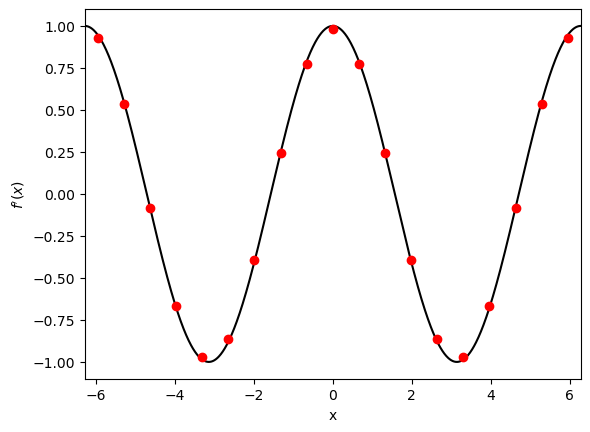

In [18]:
f = lambda x: numpy.sin(x)              # Definisikan fungsi kontinu (sinus)
f_prime = lambda x: numpy.cos(x)        # Definisikan turunan analitik (kosinus) sebagai referensi

# Inisialisasi diskretisasi domain seragam pada sumbu x
x = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, 1000) # Grid halus untuk plot referensi
N = 20                                               # Jumlah titik sampel diskret
x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N) # Grid diskret untuk komputasi numerik
delta_x = x_hat[1] - x_hat[0]                        # Menghitung jarak antar titik (ukuran langkah)
print("%s = %s" % (delta_x, (x_hat[-1] - x_hat[0]) / (N - 1))) # Verifikasi konsistensi nilai delta_x

# Komputasi turunan numerik menggunakan skema Perbedaan Maju (Forward Difference)
f_prime_hat = numpy.empty(x_hat.shape)               # Alokasi memori untuk hasil turunan
for i in range(N - 1):                               # Iterasi melalui titik kisi (kecuali titik akhir)
    f_prime_hat[i] = (f(x_hat[i+1]) - f(x_hat[i])) / delta_x # Formulasi perbedaan maju

# Implementasi skema Perbedaan Mundur (Backward Difference) pada batas akhir domain
f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x # Komputasi pada titik terakhir (x_N)

# Visualisasi perbandingan solusi eksak dan aproksimasi numerik
fig = plt.figure()                                   # Inisialisasi figur plotting
axes = fig.add_subplot(1, 1, 1)                      # Penentuan tata letak subplot

axes.plot(x, f_prime(x), 'k')                        # Plot fungsi turunan analitik (garis hitam)
axes.plot(x_hat + 0.5 * delta_x, f_prime_hat, 'ro')  # Plot hasil numerik pada titik tengah (simbol merah)
axes.set_xlim((x[0], x[-1]))                         # Pengaturan batas sumbu horizontal
axes.set_ylim((-1.1, 1.1))                           # Pengaturan batas sumbu vertikal
axes.set_xlabel("x")                                 # Labeling sumbu x
axes.set_ylabel(r"$f'(x)$")                          # Labeling sumbu y menggunakan notasi LaTeX

plt.show()                                           # Prosedur untuk menampilkan grafik hasil

### Contoh: Derivatif Orde Kedua (Second Order Derivative)

Dengan menggunakan pendekatan deret Taylor, mari kita turunkan rumus turunan kedua yang akurat orde kedua.  Sekali lagi kita akan menggunakan titik yang sama dan deret Taylor berpusat di $x = x_n$ sehingga kita mendapatkan ekspresi yang sama seperti sebelumnya:

 $$\begin{aligned}
    u''(x_n) + R(x_n) &= \quad A \left ( u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) + \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) + \mathcal{O}(\Delta x^5)\right ) \\
    &\quad+ B u(x_n) \\
    &\quad+ C \left ( u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) - \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) + \mathcal{O}(\Delta x^5) \right )
\end{aligned}$$ 

kecuali kali ini kami ingin meninggalkan $u''(x_n)$ di sisi kanan.  Melakukan trik yang sama seperti sebelumnya kita memiliki ekspresi berikut:

 $$\begin{aligned}
    u(x_n): & \quad A + B + C = 0 \\
    u'(x_n): & \quad A \Delta x - C \Delta x = 0 \\
    u''(x_n): & \quad A \frac{\Delta x^2}{2} + C \frac{\Delta x^2}{2} = 1
\end{aligned}$$

Persamaan kedua menyiratkan $A = C$ yang dikombinasikan dengan persamaan ketiga

 $$A = C = \frac{1}{\Delta x^2}$$

Akhirnya persamaan pertama memberi

 $$B = -\frac{2}{\Delta x^2}$$

mengarah ke ekspresi akhir

$$\begin{aligned} u''(x_n) + R(x_n) &= \frac{u(x_{n+1}) - 2 u(x_n) + u(x_{n-1})}{\Delta x^2} \\ &\quad+ \frac{1}{\Delta x^2} \left(\frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n)  - \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n)  \right) + \mathcal{O}(\Delta x^5)
\end{aligned}$$

dengan

 $$R(x_n) = \frac{\Delta x^2}{12} u^{(4)}(x_n) + \mathcal{O}(\Delta x^3)$$

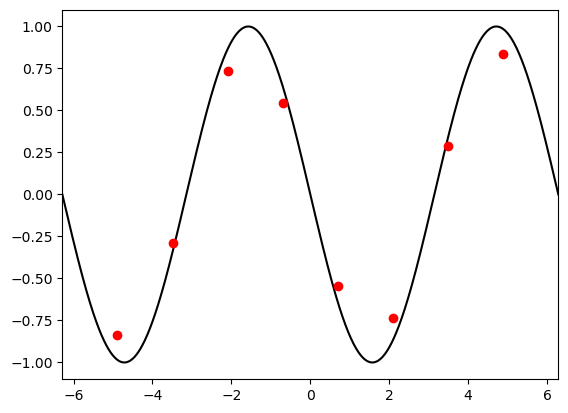

In [19]:
f = lambda x: numpy.sin(x)              # Definisikan fungsi kontinu asli (sinus)
f_dubl_prime = lambda x: -numpy.sin(x)  # Definisikan turunan kedua analitik sebagai referensi eksak

# Implementasi diskretisasi domain seragam
x = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, 1000) # Grid halus untuk visualisasi referensi
N = 10                                               # Jumlah titik sampel diskret (node)
x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N) # Grid diskret untuk kalkulasi numerik
delta_x = x_hat[1] - x_hat[0]                        # Menghitung interval spasial antar titik kisi

# Komputasi turunan kedua menggunakan skema Perbedaan Terpusat
f_dubl_prime_hat = numpy.empty(x_hat.shape)          # Alokasi memori untuk hasil turunan kedua numerik
# Formulasi perbedaan terpusat orde kedua untuk titik interior domain:
f_dubl_prime_hat[1:-1] = (f(x_hat[2:]) - 2.0 * f(x_hat[1:-1]) + f(x_hat[:-2])) / (delta_x**2)

# Penanganan syarat batas menggunakan skema perbedaan orde tinggi (one-sided)
# Titik awal (x_0) menggunakan skema perbedaan maju orde kedua:
f_dubl_prime_hat[0] = (2.0 * f(x_hat[0]) - 5.0 * f(x_hat[1]) + 4.0 * f(x_hat[2]) - f(x_hat[3])) / delta_x**2
# Titik akhir (x_N) menggunakan skema perbedaan mundur orde kedua:
f_dubl_prime_hat[-1] = (2.0 * f(x_hat[-1]) - 5.0 * f(x_hat[-2]) + 4.0 * f(x_hat[-3]) - f(x_hat[-4])) / delta_x**2

# Visualisasi perbandingan hasil komputasi
fig = plt.figure()                                   # Inisialisasi jendela grafik
axes = fig.add_subplot(1, 1, 1)                      # Penentuan sistem koordinat tunggal

axes.plot(x, f_dubl_prime(x), 'k')                   # Plot solusi eksak turunan kedua (garis hitam)
axes.plot(x_hat, f_dubl_prime_hat, 'ro')             # Plot hasil aproksimasi numerik (simbol merah)
axes.set_xlim((x[0], x[-1]))                         # Pengaturan rentang sumbu horizontal
axes.set_ylim((-1.1, 1.1))                           # Pengaturan rentang sumbu vertikal

plt.show()                                           # Prosedur penayangan visualisasi hasil

### **Derivasi Umum(General Derivation)**

Untuk perkiraan perbedaan hingga umum yang terletak di $\bar{x}$ ke turunan ke $k$ dengan stensil arbitrer $N \geq k + 1$ poin $x_1, \ldots, x_N$ kita dapat menggunakan beberapa generalisasi dari metode di atas.  Perhatikan bahwa meskipun $\bar{x}$ adalah salah satu titik stensil, hal ini tidak diperlukan.  Kami juga berasumsi bahwa $u(x)$ cukup mulus sehingga deret Taylor kami valid.

Pada setiap titik stensil kami memiliki perkiraannya
 $$
    u(x_i) = u(\bar{x}) + (x_i - \bar{x})u'(\bar{x}) + \cdots + \frac{1}{k!}(x_i - \bar{x})^k u^{(k)}(\bar{x}) + \cdots.
$$

Mengikuti metodologi kami di atas, kami ingin mencari kombinasi linier dari ekspansi deret Taylor sedemikian rupa
 $$
    u^{(k)}(\bar{x}) + \mathcal{O}(\Delta x^p) = a_1 u(x_1) + a_2 u(x_2) + a_3 u(x_3) + \cdots + a_n u(x_n).
$$ 
Perhatikan bahwa $\Delta x$ dapat bervariasi secara umum dan perilaku asimtotik metode ini akan ditandai dengan semacam jarak rata-rata atau terkadang jarak maksimum antara titik-titik stensil.

Menggeneralisasi pendekatan di atas dengan metode koefisien tak tentu, kami ingin menghilangkan potongan perkiraan di atas yang berada di depan turunan kurang dari orde $k$.  Syaratnya adalah
 $$
    \frac{1}{(i - 1)!} \sum^N_{j=1} a_j (x_j - \bar{x})^{(i-1)} = \left \{ \begin{aligned}
        1 & & \text{if} \quad i - 1 = k, \\
        0 & & \text{otherwise}
    \end{aligned} \right .
$$ 
untuk $i=1, \ldots, N$ .  Dengan asumsi $x_j$ berbeda, kita dapat menulis sistem persamaan dalam sistem Vandermonde yang akan memiliki solusi unik.

In [20]:
import scipy.special

def finite_difference(k, x_bar, x):
    """Menghitung stensil perbedaan hingga untuk turunan ke-k"""
    
    N = x.shape[0]                                     # Menentukan jumlah titik dalam stensil
    A = numpy.ones((N, N))                             # Inisialisasi matriks sistem linear (Matriks Vandermonde modifikasi)
    x_row = x - x_bar                                  # Menghitung jarak relatif titik terhadap titik evaluasi (x_bar)
    for i in range(1, N):                              # Membangun baris matriks berdasarkan ekspresi Taylor
        A[i, :] = x_row ** i / scipy.special.factorial(i) # Normalisasi elemen menggunakan fungsi faktorial
    
    b = numpy.zeros(N)                                 # Inisialisasi vektor target (ruas kanan)
    b[k] = 1.0                                         # Menentukan turunan ke-k yang ingin diisolasi
    
    c = numpy.linalg.solve(A, b)                       # Menyelesaikan sistem persamaan linear untuk mencari koefisien stensil
    return c                                           # Mengembalikan vektor koefisien c

# Contoh penggunaan untuk berbagai orde turunan dan konfigurasi stensil:
# Menghitung koefisien turunan kedua (k=2) pada stensil terpusat 3 titik [-1, 0, 1]
print(finite_difference(2, 0.0, numpy.asarray([-1.0, 0.0, 1.0])))

# Menghitung koefisien turunan pertama (k=1) pada stensil terpusat 3 titik [-1, 0, 1]
print(finite_difference(1, 0.0, numpy.asarray([-1.0, 0.0, 1.0])))

# Menghitung koefisien turunan pertama (k=1) pada stensil maju 5 titik
print(finite_difference(1, -2.0, numpy.asarray([-2.0, -1.0, 0.0, 1.0, 2.0])))

# Menghitung koefisien turunan kedua (k=2) pada stensil asimetris 6 titik (dikalikan konstanta 12)
print(finite_difference(2, 0.0, numpy.asarray([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])) * 12)

[ 1. -2.  1.]
[-0.5  0.   0.5]
[-2.08333333  4.         -3.          1.33333333 -0.25      ]
[ 10. -15.  -4.  14.  -6.   1.]


## **Analisis Kesalahan (Error Analysis)**

### Tampilan Polinomial

Dengan adanya poin $N + 1$ kita dapat membentuk $P_N(x)$ derajat $N$ interpolan di mana

 $$u(x) = P_N(x) + R_N(x)$$

Kita tahu dari Teorema Lagrange seperti apa suku sisanya

 $$R_N(x) = (x - x_0)(x - x_1)\cdots (x - x_{N})(x - x_{N+1}) \frac{u^{(N+1)}(c)}{(N+1)!}$$

mencatat bahwa kita perlu memerlukan $u(x) \in C^{N+1}$ pada interval yang diinginkan.  Mengambil turunan dari interpolant $P_N(x)$ (dalam polinomial Newton) kemudian menghasilkan 

 $$\begin{aligned} P_N'(x) &= [u(x_0), u(x_1)] + ((x - x_1) + (x - x_0)) [u(x_0), u(x_1), u(x_2)]+ \cdots \\ &\quad  + \left(\sum^{N-1}_{i=0}\left( \prod^{N-1}_{j=0,~j\neq i} (x - x_j) \right )\right ) [u(x_0), u(x_1), \ldots, u(x_N)] \end{aligned}$$

Demikian pula kita dapat mencari turunan dari suku sisa $R_N(x)$ sebagai

 $$R_N'(x) = \left(\sum^{N}_{i=0} \left( \prod^{N}_{j=0,~j\neq i} (x - x_j) \right )\right ) \frac{u^{(N+1)}(c)}{(N+1)!}$$

Sekarang jika kita mempertimbangkan perkiraan turunan yang dievaluasi pada salah satu titik data kita $(x_k, y_k)$, ekspresi ini disederhanakan sedemikian rupa sehingga

 $$u'(x_k) = P_N'(x_k) + R_N'(x_k)$$

Jika kita membiarkan $\Delta x = \max_i |x_k - x_i|$ maka kita mengetahui bahwa suku sisanya adalah $\mathcal{O}(\Delta x^N)$ sebagai $\Delta x \rightarrow 0$ sehingga menunjukkan bahwa pendekatan ini konvergen dan kita dapat menemukan perkiraan tingkat tinggi yang sewenang-wenang.

### Kesalahan Pemotongan

Jika kita menggunakan pendekatan deret Taylor, kita juga dapat melihat suku dominan yang tersisa dari deret Taylor untuk mencari *kesalahan pemotongan*.

Sebagai contoh, mari kita perhatikan kembali perkiraan turunan pertama di atas, kita memerlukan ekspansi Taylor
 $$
    u(\bar{x} + \Delta x) = u(\bar{x}) + \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$ 
dan
 $$
    u(\bar{x} - \Delta x) = u(\bar{x}) - \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) - \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4).
$$

Memasukkan ini ke dalam ekspresi yang kita miliki
 $$\begin{aligned}
    D_+ u(\bar{x}) &= \frac{u(\bar{x} + \Delta x) - u(\bar{x})}{\Delta x} \\
    &= \frac{\Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)}{\Delta x} \\
    &= u'(\bar{x}) + \frac{1}{2} \Delta x u''(\bar{x}) + \frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^3).
\end{aligned}$$

Jika sekarang kita membedakan $D_+ u(\bar{x}) - u'(\bar{x})$ kita mendapatkan kesalahan pemotongan
 $$
    \frac{1}{2} \Delta x u''(\bar{x}) + \frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^3)
$$ 
jadi kesalahan untuk $D_+$ menjadi $\mathcal{O}(\Delta x)$ dan dikontrol oleh $u''(\bar{x})$ .  Perhatikan bahwa perkiraan ini bergantung pada $\Delta x$ karena turunan yang dievaluasi pada $\bar{x}$ adalah konstanta.

Demikian pula untuk pendekatan terpusat yang kita miliki
 $$
    D_0 u(\bar{x}) - u'(\bar{x}) = \frac{1}{6} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^4).
$$

### **Menghitung Urutan Akurasi Secara Grafis(Computing Order of Accuracy Graphically)**

Modelkan kesalahannya sebagai
 $$\begin{aligned}
    e(\Delta x) &= C \Delta x^n \\
    \log e(\Delta x) &= \log C + n \log \Delta x
\end{aligned}$$ 

Kemiringan garis adalah $n$ saat menghitung ini!  Kita juga dapat mencocokkan poin pertama dengan menyelesaikan $C$ :

 $$C = e^{\log e(\Delta x) - n \log \Delta x}$$

<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\h'
<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_181636\3869813589.py:41: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_181636\3869813589.py:42: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$")


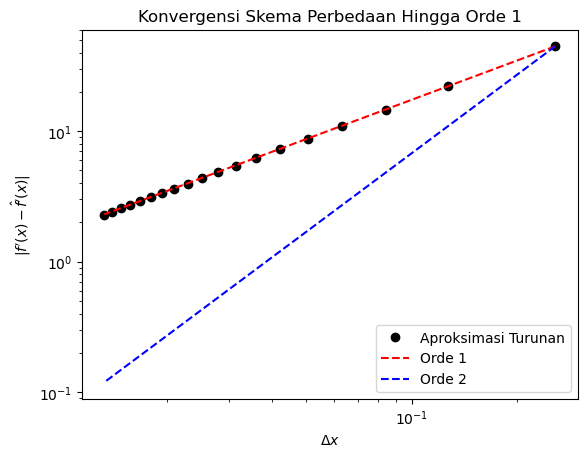

In [21]:
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3       # Definisi fungsi target non-linear
f_prime = lambda x: numpy.cos(x) + 2.0 * x + 9.0 * x**2 # Definisi turunan eksak sebagai referensi galat

# Inisialisasi variabel untuk analisis hubungan antara delta_x dan galat
delta_x = []                                         # Larik untuk menyimpan nilai interval spasial
error = []                                           # Larik untuk menyimpan nilai galat maksimum (norma tak hingga)

# Iterasi penambahan jumlah titik (N) untuk mengevaluasi laju konvergensi
for N in range(50, 1000, 50):
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N) # Diskretisasi domain secara seragam
    delta_x.append(x_hat[1] - x_hat[0])              # Menghitung ukuran langkah spasial saat ini

    # Komputasi turunan numerik menggunakan skema Perbedaan Maju (Forward Difference)
    f_prime_hat = numpy.empty(x_hat.shape)           # Alokasi memori untuk hasil aproksimasi
    f_prime_hat[:-1] = (f(x_hat[1:]) - f(x_hat[:-1])) / (delta_x[-1])

    # Penerapan skema Perbedaan Mundur (Backward Difference) pada batas akhir domain
    f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x[-1] 
    
    # Menghitung galat maksimum menggunakan norma-infinitas terhadap solusi eksak
    error.append(numpy.linalg.norm(numpy.abs(f_prime(x_hat + delta_x[-1]) - f_prime_hat), ord=numpy.inf))
    
error = numpy.array(error)                           # Konversi list galat menjadi array NumPy
delta_x = numpy.array(delta_x)                       # Konversi list delta_x menjadi array NumPy
    
# Visualisasi Log-Log untuk menentukan orde akurasi numerik
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot galat aproksimasi dalam skala logaritma
axes.loglog(delta_x, error, 'ko', label="Aproksimasi Turunan")

# Fungsi untuk menghitung garis referensi orde kemiringan (slope)
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
axes.loglog(delta_x, order_C(delta_x[0], error[0], 1.0) * delta_x**1.0, 'r--', label="Orde 1")
axes.loglog(delta_x, order_C(delta_x[0], error[0], 2.0) * delta_x**2.0, 'b--', label="Orde 2")

# Pengaturan anotasi dan label grafik ilmiah
axes.legend(loc=4)
axes.set_title("Konvergensi Skema Perbedaan Hingga Orde 1")
axes.set_xlabel("$\Delta x$")
axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$")

plt.show()                                           # Eksekusi penampilan grafik analisis galat

<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\h'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_181636\558737997.py:43: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_181636\558737997.py:44: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$")


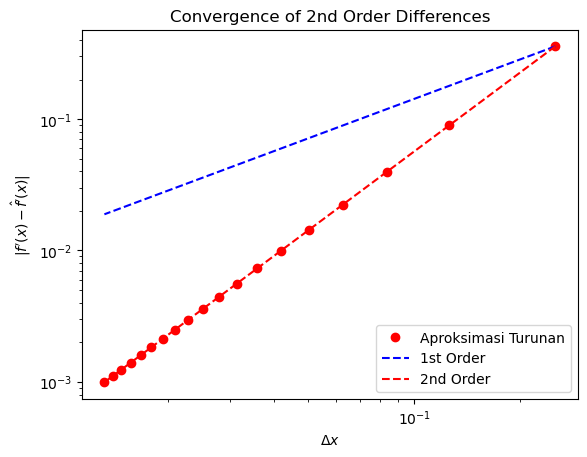

In [22]:
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3       # Definisi fungsi target non-linear
f_prime = lambda x: numpy.cos(x) + 2.0 * x + 9.0 * x**2 # Definisi turunan eksak sebagai referensi galat

# Inisialisasi variabel untuk analisis hubungan antara delta_x dan galat
delta_x = []                                         # Larik untuk menyimpan nilai interval spasial
error = []                                           # Larik untuk menyimpan nilai galat maksimum

# Iterasi peningkatan densitas grid untuk mengevaluasi laju konvergensi
for N in range(50, 1000, 50):
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N + 1) # Diskretisasi domain seragam
    delta_x.append(x_hat[1] - x_hat[0])              # Menghitung ukuran langkah spasial (grid spacing)

    # Komputasi turunan numerik menggunakan skema Perbedaan Terpusat (Central Difference)
    f_prime_hat = numpy.empty(x_hat.shape)           # Alokasi memori untuk hasil aproksimasi
    # Skema perbedaan terpusat memiliki orde akurasi O(Δx^2) untuk titik interior:
    f_prime_hat[1:-1] = (f(x_hat[2:]) - f(x_hat[:-2])) / (2 * delta_x[-1])

    # Penanganan syarat batas menggunakan skema perbedaan orde kedua (one-sided)
    # Titik awal (x_0) menggunakan skema maju orde kedua:
    f_prime_hat[0] = (-3.0 * f(x_hat[0]) + 4.0 * f(x_hat[1]) - f(x_hat[2])) / (2.0 * delta_x[-1])
    # Titik akhir (x_N) menggunakan skema mundur orde kedua:
    f_prime_hat[-1] = (3.0 * f(x_hat[-1]) - 4.0 * f(x_hat[-2]) + f(x_hat[-3])) / (2.0 * delta_x[-1])
    
    # Menghitung galat maksimum menggunakan norma-infinitas terhadap solusi eksak
    error.append(numpy.linalg.norm(numpy.abs(f_prime(x_hat) - f_prime_hat), ord=numpy.inf))
    
error = numpy.array(error)                           # Konversi list galat menjadi array NumPy
delta_x = numpy.array(delta_x)                       # Konversi list delta_x menjadi array NumPy
    
# Visualisasi Log-Log untuk memverifikasi orde akurasi numerik
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot galat aproksimasi dalam skala logaritma (simbol merah)
axes.loglog(delta_x, error, "ro", label="Aproksimasi Turunan")

# Fungsi untuk memetakan garis referensi kemiringan orde konvergensi
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
axes.loglog(delta_x, order_C(delta_x[0], error[0], 1.0) * delta_x**1.0, 'b--', label="1st Order")
axes.loglog(delta_x, order_C(delta_x[0], error[0], 2.0) * delta_x**2.0, 'r--', label="2nd Order")
axes.legend(loc=4)
axes.set_title("Convergence of 2nd Order Differences")
axes.set_xlabel("$\Delta x$")
axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$")

plt.show()

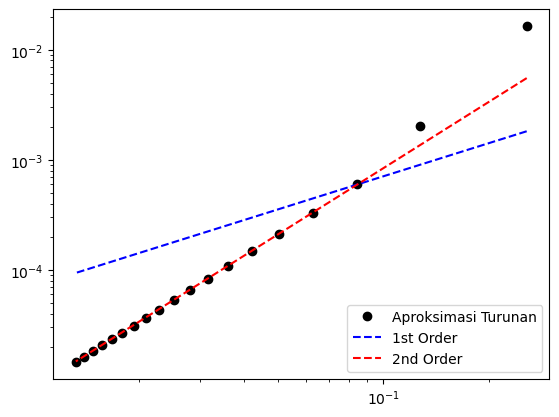

In [23]:
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3       # Definisi fungsi target non-linear
f_dubl_prime = lambda x: -numpy.sin(x) + 2.0 + 18.0 * x # Definisi turunan kedua eksak sebagai referensi

# Inisialisasi variabel untuk analisis hubungan antara delta_x dan galat
delta_x = []                                         # Larik untuk menyimpan nilai interval spasial
error = []                                           # Larik untuk menyimpan nilai galat maksimum (norma infinitas)

# Iterasi peningkatan densitas grid untuk mengevaluasi laju konvergensi
for N in range(50, 1000, 50):
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N) # Diskretisasi domain seragam
    delta_x.append(x_hat[1] - x_hat[0])              # Menghitung ukuran langkah spasial (delta x)

    # Komputasi turunan kedua numerik
    f_dubl_prime_hat = numpy.empty(x_hat.shape)      # Alokasi memori untuk hasil aproksimasi
    # Skema perbedaan terpusat orde kedua untuk titik interior:
    f_dubl_prime_hat[1:-1] = (f(x_hat[2:]) - 2.0 * f(x_hat[1:-1]) + f(x_hat[:-2])) / (delta_x[-1]**2)

    # Penanganan syarat batas menggunakan skema perbedaan orde kedua (one-sided)
    # Formulasi ini tetap menjaga akurasi orde kedua pada titik ujung domain:
    f_dubl_prime_hat[0] = (2.0 * f(x_hat[0]) - 5.0 * f(x_hat[1]) + 4.0 * f(x_hat[2]) - f(x_hat[3])) / delta_x[-1]**2
    f_dubl_prime_hat[-1] = (2.0 * f(x_hat[-1]) - 5.0 * f(x_hat[-2]) + 4.0 * f(x_hat[-3]) - f(x_hat[-4])) / delta_x[-1]**2
    
    # Perhitungan galat maksimum dibandingkan dengan solusi analitik
    error.append(numpy.linalg.norm(numpy.abs(f_dubl_prime(x_hat) - f_dubl_prime_hat), ord=numpy.inf))
    
error = numpy.array(error)                           # Konversi hasil galat ke format array
delta_x = numpy.array(delta_x)                       # Konversi delta_x ke format array
    
# Visualisasi Log-Log untuk analisis orde konvergensi
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot galat hasil komputasi (simbol titik hitam)
axes.loglog(delta_x, error, "ko", label="Aproksimasi Turunan")

# Fungsi untuk memetakan garis referensi kemiringan orde 1 dan orde 2
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
axes.loglog(delta_x, order_C(delta_x[2], error[2], 1.0) * delta_x**1.0, 'b--', label="1st Order")
axes.loglog(delta_x, order_C(delta_x[2], error[2], 2.0) * delta_x**2.0, 'r--', label="2nd Order")
axes.legend(loc=4)